In [1]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

## training a VAE

In [2]:
import torch
import rdkit
from rdkit import Chem
print(torch.__version__)
print(Chem.MolFromSmiles("CCO"))

2.11.0


In [3]:
from tdc.single_pred import ADME

data = ADME(name='CYP2D6_Veith')
df = data.get_data()
print(df.shape)
df.head()

Found local copy...
Loading...
Done!


(13130, 3)


,Drug_ID,Drug,Y
0,1960010.0,CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21,0
1,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,0
2,644890.0,COc1ccccc1C(c1nnnn1C(C)(C)C)N1CCN(Cc2ccncc2)CC1,1
3,645063.0,CC(=O)Nc1cccc(NC(=O)C2CCCN2C(=O)Nc2ccccc2C)c1,0
4,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0


## building the character vocabulary
we start off by building the character vocabulary, since a VAE encodes smiles strings into a latent vector. a neural network cant take raw text - only numbers, so we convert each character in a smiles string to an integer.

`<pad>` - used to make all SMILES the same length in a batch (token = 0)

`<sos>` - start of sequence, tells the decoder to begin generating (token = 1)

`<eos>` - end of sequence, tells the decoder to stop (token = 2)

!!!! this can raise an issue because neural networks care abt what the numbers mean - check the thing with 0 and 1s (one hot encodding)

In [4]:
smiles_list = df['Drug'].tolist()

vocab = sorted(set(''.join(smiles_list)))
vocab = ['<pad>', '<sos>', '<eos>'] + vocab

char2idx = {ch: idx for idx, ch in enumerate(vocab)} # given a character, return its index
idx2char = {idx: ch for ch, idx in char2idx.items()} # given an index, return its character

print(f"Vocabulary size: {len(vocab)}")
print(f"Characters: {vocab}")

Vocabulary size: 55
Characters: ['<pad>', '<sos>', '<eos>', '#', '%', '(', ')', '+', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'W', 'Z', '[', '\\', ']', 'a', 'b', 'c', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's', 't', 'u']


Next step is to check the distribution of SMILES lengths to configure padding

Max length: 402
Mean length: 46.1
95th percentile: 84


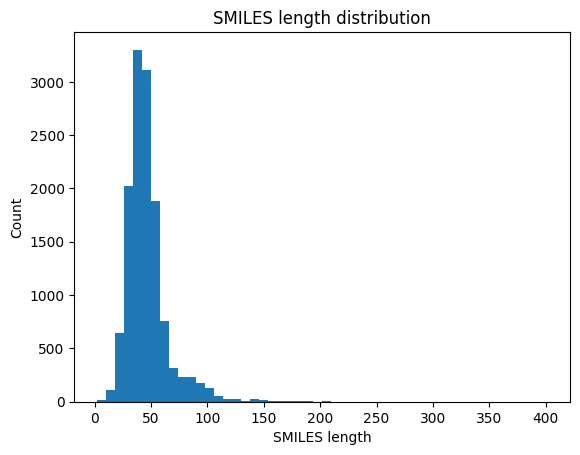

In [5]:
import matplotlib.pyplot as plt

lengths = [len(s) for s in smiles_list]
print(f"Max length: {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.1f}")
print(f"95th percentile: {sorted(lengths)[int(0.95*len(lengths))]}")

plt.hist(lengths, bins=50)
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.title("SMILES length distribution")
plt.show()

the distribution is right-skewed, with a mean length of smiles strings being 46.1 (small molecules) and the 95th percentile is 85, so we set `max_length` = 100

## Tokenization and Encoding of SMILES 

In [6]:
import torch

MAX_LENGTH = 100

def encode_smiles(smiles, char2idx, max_length):
    """
    Convert a SMILES string to a fixed-length integer sequence.
    
    Wraps the sequence with <sos> and <eos> tokens, truncates sequences
    longer than max_length, and pads shorter sequences with <pad> tokens.
    
    Args:
        smiles (str): SMILES string of a molecule.
        char2idx (dict): mapping from character to integer index.
        max_length (int): fixed length for all output sequences.
    
    Returns:
        list[int]: integer-encoded sequence of length max_length.
    """
    tokens = ['<sos>'] + list(smiles) + ['<eos>']
    tokens = tokens[:max_length]
    tokens += ['<pad>'] * (max_length - len(tokens))
    return [char2idx[t] for t in tokens]


In [7]:
# Test on one SMILES
example = smiles_list[0]
encoded = encode_smiles(example, char2idx, MAX_LENGTH)
print(f"SMILES: {example}")
print(f"Encoded: {encoded}")
print(f"Length: {len(encoded)}")

SMILES: CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21
Encoded: [1, 25, 25, 32, 12, 25, 5, 21, 33, 6, 10, 25, 5, 21, 25, 13, 40, 36, 25, 5, 21, 36, 6, 32, 5, 25, 25, 25, 33, 25, 6, 25, 13, 21, 33, 6, 44, 13, 44, 44, 44, 44, 44, 13, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 100


In [8]:
# encode the entire dataset
encoded_data = [encode_smiles(s, char2idx, MAX_LENGTH) for s in smiles_list]
encoded_data = torch.tensor(encoded_data, dtype=torch.long)
print(encoded_data.shape)

torch.Size([13130, 100])


## build the pytorch dataset and dataloader

In [9]:
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem

ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
ATOM_FEAT_DIM = len(ATOM_TYPES) + 1 + 4  # one-hot type + other + degree + charge + aromatic + numHs
MAX_ATOMS = 60

def atom_features(atom):
    sym = atom.GetSymbol()
    type_oh = [int(sym == t) for t in ATOM_TYPES] + [int(sym not in ATOM_TYPES)]
    degree      = min(atom.GetDegree(), 6)
    charge      = max(min(atom.GetFormalCharge(), 2), -2)
    aromatic    = int(atom.GetIsAromatic())
    num_hs      = min(atom.GetTotalNumHs(), 4)
    return type_oh + [degree, charge, aromatic, num_hs]

def smiles_to_graph(smiles, max_atoms=MAX_ATOMS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    n = mol.GetNumAtoms()
    if n > max_atoms:
        return None
    feat_dim = len(ATOM_TYPES) + 1 + 4
    atom_feats = torch.zeros(max_atoms, feat_dim)
    for i, a in enumerate(mol.GetAtoms()):
        atom_feats[i] = torch.tensor(atom_features(a), dtype=torch.float)
    adj = torch.zeros(max_atoms, max_atoms)
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        adj[i, j] = adj[j, i] = 1.0
    adj[:n, :n] += torch.eye(n)  # self-loops
    deg = adj.sum(dim=1, keepdim=True).clamp(min=1)
    adj_norm = adj / deg           # D^{-1} A normalisation
    mask = torch.zeros(max_atoms)
    mask[:n] = 1.0
    return atom_feats, adj_norm, mask

# Pre-compute graphs and keep only molecules that fit in MAX_ATOMS
graph_data = []
valid_indices = []
for i, smi in enumerate(smiles_list):
    result = smiles_to_graph(smi)
    if result is not None:
        graph_data.append(result)
        valid_indices.append(i)

encoded_data_filtered = encoded_data[valid_indices]
print(f"Molecules kept (≤{MAX_ATOMS} atoms): {len(valid_indices)} / {len(smiles_list)}")
print(f"Atom feature dim: {ATOM_FEAT_DIM}")

class MolGraphDataset(Dataset):
    """Returns (token_sequence, atom_feats, adj_norm, mask) per molecule."""
    def __init__(self, encoded_data, graph_data):
        self.seqs   = encoded_data
        self.graphs = graph_data

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        atom_feats, adj, mask = self.graphs[idx]
        return self.seqs[idx], atom_feats, adj, mask

dataset    = MolGraphDataset(encoded_data_filtered, graph_data)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")


Molecules kept (≤60 atoms): 13093 / 13130
Atom feature dim: 14
Dataset size: 13093
Number of batches: 205


## VAE Model

The VAE consists of three components:
- **Encoder** (GNN): represents the molecule as a graph, runs 3 graph convolutional layers,
  then mean-pools node embeddings into a graph-level vector and projects to a latent
  distribution via two linear heads.
- **Reparameterisation**: samples from the latent distribution while keeping the computation
  graph differentiable.
- **Decoder** (GRU): reconstructs the SMILES sequence autoregressively from the latent vector.

In [10]:
import torch.nn as nn
import torch.nn.functional as F


class GNNEncoder(nn.Module):
    """
    Encodes a molecular graph into a latent distribution (mu, log_var) using
    three graph convolutional layers (GCN-style: h = ReLU(A_norm @ h @ W))
    followed by masked mean pooling and two linear projection heads.

    Args:
        atom_feat_dim (int): dimension of per-atom input features.
        hidden_dim (int): width of each GCN layer.
        latent_dim (int): dimension of the latent space.
    """
    def __init__(self, atom_feat_dim, hidden_dim, latent_dim):
        super().__init__()
        self.conv1 = nn.Linear(atom_feat_dim, hidden_dim)
        self.conv2 = nn.Linear(hidden_dim, hidden_dim)
        self.conv3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, atom_feats, adj, mask):
        """
        Args:
            atom_feats (Tensor): (batch, max_atoms, atom_feat_dim)
            adj        (Tensor): normalised adjacency, (batch, max_atoms, max_atoms)
            mask       (Tensor): real-atom mask, (batch, max_atoms)

        Returns:
            mu      (Tensor): (batch, latent_dim)
            log_var (Tensor): (batch, latent_dim)
        """
        h = F.relu(torch.bmm(adj, self.conv1(atom_feats)))  # (B, A, H)
        h = F.relu(torch.bmm(adj, self.conv2(h)))
        h = F.relu(torch.bmm(adj, self.conv3(h)))

        # Masked mean pooling over atoms
        mask_exp = mask.unsqueeze(-1)                        # (B, A, 1)
        h = (h * mask_exp).sum(dim=1) / mask.sum(dim=1, keepdim=True).clamp(min=1)
        # h: (B, H)

        return self.fc_mu(h), self.fc_logvar(h)
# keep old name as alias so later cells that reference 'Encoder' still work
Encoder = GNNEncoder


### Reparameterisation

The encoder outputs `mu` and `log_var`, which define a probability distribution in latent space.
We sample a latent vector `z` from this distribution using the reparameterisation trick.
This allows gradients to flow through the sampling step during backpropagation.

trick to make it differntiable

In [11]:
def reparameterise(mu, log_var):
    """
    Sample a latent vector z using the reparameterisation trick.
    
    Instead of sampling z directly from N(mu, std), we sample epsilon from N(0,1)
    and compute z = mu + epsilon * std. This keeps the sampling step differentiable.
    
    Args:
        mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
    
    Returns:
        z (Tensor): sampled latent vector, shape (batch_size, latent_dim).
    """
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

### Decoder

The decoder takes the latent vector z and reconstructs the SMILES sequence token by token.
It uses a GRU that generates one token at a time, conditioned on z.

In [12]:
class Decoder(nn.Module):
    """
    Decodes a latent vector z into a SMILES sequence autoregressively.
    
    z is repeated across all timesteps via RepeatVector and concatenated
    with the one-hot token input at each step, so the GRU sees z at every
    timestep rather than only at initialisation. Hard teacher forcing is used
    during training.
    
    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        hidden_dim (int): hidden dimension of the GRU.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers.
    """
    def __init__(self, vocab_size, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        self.fc_z = nn.Linear(latent_dim, hidden_dim * n_layers)
        self.gru = nn.GRU(vocab_size + latent_dim, hidden_dim, n_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, z, x):
        """
        Args:
            z (Tensor): latent vector, shape (batch_size, latent_dim).
            x (Tensor): target sequence, shape (batch_size, seq_len).
        
        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
        """
        hidden = self.fc_z(z)
        hidden = hidden.view(-1, self.n_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        seq_len = x.size(1) - 1
        x_onehot = F.one_hot(x[:, :-1], num_classes=self.vocab_size).float()  # (batch, seq_len-1, vocab_size)
        z_repeated = z.unsqueeze(1).expand(-1, seq_len, -1)                   # (batch, seq_len-1, latent_dim)
        gru_input = torch.cat([x_onehot, z_repeated], dim=-1)                 # (batch, seq_len-1, vocab_size + latent_dim)

        output, _ = self.gru(gru_input, hidden)
        logits = self.fc_out(output)
        return logits

In [13]:
class VAE(nn.Module):
    """
    Variational Autoencoder for SMILES strings with a GNN encoder.

    The GNN encoder processes the molecular graph; a latent vector z is sampled
    via reparameterisation; the GRU decoder reconstructs the SMILES token sequence.

    Args:
        vocab_size     (int): number of unique tokens.
        atom_feat_dim  (int): per-atom feature dimension fed to the GNN.
        gnn_hidden_dim (int): hidden width of GCN layers.
        hidden_dim     (int): hidden dimension of the GRU decoder.
        latent_dim     (int): latent space dimension.
        n_layers       (int): number of GRU layers.
    """
    def __init__(self, vocab_size, atom_feat_dim, gnn_hidden_dim,
                 hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.encoder = GNNEncoder(atom_feat_dim, gnn_hidden_dim, latent_dim)
        self.decoder = Decoder(vocab_size, hidden_dim, latent_dim, n_layers)

    def forward(self, x, atom_feats, adj, mask):
        """
        Args:
            x          (Tensor): token sequence, (batch, seq_len).
            atom_feats (Tensor): (batch, max_atoms, atom_feat_dim)
            adj        (Tensor): (batch, max_atoms, max_atoms)
            mask       (Tensor): (batch, max_atoms)

        Returns:
            logits  (Tensor): (batch, seq_len-1, vocab_size)
            mu      (Tensor): (batch, latent_dim)
            log_var (Tensor): (batch, latent_dim)
        """
        mu, log_var = self.encoder(atom_feats, adj, mask)
        z = reparameterise(mu, log_var)
        logits = self.decoder(z, x)
        return logits, mu, log_var


In [14]:
VOCAB_SIZE     = len(vocab)
GNN_HIDDEN_DIM = 256
HIDDEN_DIM     = 512
LATENT_DIM     = 128
N_LAYERS       = 2

model = VAE(VOCAB_SIZE, ATOM_FEAT_DIM, GNN_HIDDEN_DIM, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


VAE(
  (encoder): GNNEncoder(
    (conv1): Linear(in_features=14, out_features=256, bias=True)
    (conv2): Linear(in_features=256, out_features=256, bias=True)
    (conv3): Linear(in_features=256, out_features=256, bias=True)
    (fc_mu): Linear(in_features=256, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc_z): Linear(in_features=128, out_features=1024, bias=True)
    (gru): GRU(183, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=55, bias=True)
  )
)
Total parameters: 3,008,055


In [15]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: mps


## Loss Function

The VAE loss has two components:
- Reconstruction loss: how well the decoder reconstructs the input SMILES
- KL divergence: how close the latent distribution is to a standard normal N(0,1)

Total loss = reconstruction loss + beta * KL divergence

In [ ]:
def vae_loss(logits, targets, mu, log_var, beta):
    """
    Compute the VAE loss: reconstruction loss + beta * KL divergence.
    
    Args:
        logits (Tensor): predicted token scores, shape (batch_size, seq_len, vocab_size).
        targets (Tensor): true token indices, shape (batch_size, seq_len).
        mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
        beta (float): weight on the KL term, annealed from 0 to 1 during training.
    
    Returns:
        loss (Tensor): total VAE loss.
        recon_loss (Tensor): reconstruction loss component.
        kl_loss (Tensor): KL divergence component.
    """
    # Reconstruction loss
    recon_loss = nn.CrossEntropyLoss(ignore_index=0)(
    logits.view(-1, logits.size(-1)),
    targets.reshape(-1)
    )
    
    # KL divergence
    kl_free_bits = 0.5
    kl_loss = torch.clamp(-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()), min=kl_free_bits)  # free bits: prevent KL collapsing to 0

    
    loss = recon_loss + beta * kl_loss
    return loss, recon_loss, kl_loss

## Training Loop

We train the VAE for 50 epochs. Three stabilisation techniques are combined:

- **KL annealing**: beta ramps from 0 → 1 over the first 20 epochs, then stays at 1 for the remaining 30 epochs. Separating ANNEAL_EPOCHS from EPOCHS ensures the model trains for a sustained period under full regularisation — previously both were 30, so beta never actually reached 1.0 within the run.
- **Scheduled sampling**: epsilon decays 1.0 → 0.1, gradually weaning the decoder off teacher forcing.
- **ReduceLROnPlateau**: halves the learning rate when total loss plateaus, preventing oscillation late in training.

In [17]:
def evaluate(model, dataset, vocab_size, device, idx2char, n_samples=500):
    """
    Measure reconstruction accuracy and validity on a random subset.

    Encodes graphs via GNN to mu (no noise), decodes with teacher forcing,
    then reports exact sequence match rate and RDKit validity rate.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    seqs, afeats, adjs, masks = zip(*[dataset[i] for i in indices])
    seqs   = torch.stack(seqs).to(device)
    afeats = torch.stack(afeats).to(device)
    adjs   = torch.stack(adjs).to(device)
    masks  = torch.stack(masks).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(afeats, adjs, masks)
        logits = model.decoder(mu, seqs)    # (n_samples, seq_len-1, vocab_size)
        pred_tokens = logits.argmax(dim=-1) # (n_samples, seq_len-1)

    targets  = seqs[:, 1:]
    exact_acc = (pred_tokens == targets).all(dim=1).float().mean().item()

    valid_count = 0
    for seq in pred_tokens:
        chars  = [idx2char[idx.item()] for idx in seq]
        smiles = ''
        for ch in chars:
            if ch == '<eos>': break
            if ch not in ['<pad>', '<sos>']: smiles += ch
        if smiles and Chem.MolFromSmiles(smiles) is not None:
            valid_count += 1
    validity = valid_count / n_samples

    return exact_acc, validity


## MLflow Experiment Tracking

Each training run is logged to a local MLflow experiment called `mol-vae`.  
Run `mlflow ui` in the terminal to open the tracking UI at http://localhost:5000.

In [ ]:
import mlflow
import torch.optim as optim
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter

EPOCHS         = 50
BETA_MAX       = 1.0
ANNEAL_EPOCHS  = 20
BATCH_SIZE     = 64
LEARNING_RATE  = 1e-3
KL_FREE_BITS   = 0.5

CHECKPOINT_DIR = Path('../checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri('file:///Users/elenipsaromati/mol-vae/notebooks/mlruns')
mlflow.set_experiment('mol-vae-gnn')

with mlflow.start_run():
    run_id    = mlflow.active_run().info.run_id
    model_path = CHECKPOINT_DIR / f'gnn_vae_{run_id[:8]}.pth'
    writer    = SummaryWriter(log_dir=f'../runs/gnn_{run_id[:8]}')

    mlflow.log_params({
        'vocab_size':     VOCAB_SIZE,
        'max_length':     MAX_LENGTH,
        'atom_feat_dim':  ATOM_FEAT_DIM,
        'gnn_hidden_dim': GNN_HIDDEN_DIM,
        'hidden_dim':     HIDDEN_DIM,
        'latent_dim':     LATENT_DIM,
        'n_layers':       N_LAYERS,
        'epochs':         EPOCHS,
        'anneal_epochs':  ANNEAL_EPOCHS,
        'beta_max':       BETA_MAX,
        'batch_size':     BATCH_SIZE,
        'learning_rate':  LEARNING_RATE,
        'kl_free_bits':   KL_FREE_BITS,
    })

    model = VAE(VOCAB_SIZE, ATOM_FEAT_DIM, GNN_HIDDEN_DIM, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = total_recon = total_kl = total_grad_norm = 0

        beta = min(BETA_MAX, BETA_MAX * epoch / ANNEAL_EPOCHS)

        for batch in dataloader:
            seqs, afeats, adjs, masks = batch
            seqs   = seqs.to(device)
            afeats = afeats.to(device)
            adjs   = adjs.to(device)
            masks  = masks.to(device)

            optimizer.zero_grad()
            logits, mu, log_var = model(seqs, afeats, adjs, masks)
            loss, recon_loss, kl_loss = vae_loss(logits, seqs[:, 1:], mu, log_var, beta)

            loss.backward()

            grad_norm = sum(
                p.grad.data.norm(2).item() ** 2
                for p in model.parameters() if p.grad is not None
            ) ** 0.5
            total_grad_norm += grad_norm

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()

        n_batches = len(dataloader)
        avg_loss  = total_loss / n_batches
        scheduler.step(avg_loss)

        exact_acc, validity = evaluate(model, dataset, VOCAB_SIZE, device, idx2char)
        current_lr = optimizer.param_groups[0]['lr']

        print(f'Epoch {epoch+1:>2}/{EPOCHS}, beta: {beta:.2f}, '
              f'Loss: {avg_loss:.4f}  Recon: {total_recon/n_batches:.4f}  '
              f'KL: {total_kl/n_batches:.4f}  '
              f'Grad: {total_grad_norm/n_batches:.4f}  '
              f'LR: {current_lr:.1e}')
        print(f'         Recon acc: {exact_acc:.3f}  Validity: {validity:.3f}')

        metrics = {
            'train_loss':   avg_loss,
            'recon_loss':   total_recon / n_batches,
            'kl_loss':      total_kl / n_batches,
            'grad_norm':    total_grad_norm / n_batches,
            'beta':         beta,
            'learning_rate': current_lr,
            'recon_acc':    exact_acc,
            'validity':     validity,
        }
        mlflow.log_metrics(metrics, step=epoch + 1)
        for name, value in metrics.items():
            writer.add_scalar(name, value, epoch + 1)

    torch.save(model.state_dict(), model_path)
    mlflow.set_tag('checkpoint', str(model_path.resolve()))
    writer.close()
    print(f'\nRun complete. Model saved as {model_path}')
    print(f'Run ID: {run_id}')


2026/05/07 17:00:56 INFO mlflow.tracking.fluent: Experiment with name 'mol-vae-gnn' does not exist. Creating a new experiment.


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'vae_trained5.pth')
print("Model saved")

Model saved


## Sampling evaluation

In [ ]:
from rdkit import Chem

def sample_molecules(model, num_samples, latent_dim, device, idx2char, max_length=100):
    """
    Sample molecules from the VAE using ancestral sampling.

    At each decoding step we draw the next token from the model's exact
    conditional distribution p(x_t | x_{1:t-1}, z) via multinomial sampling.
    z is concatenated to the one-hot input at every step to match the decoder
    architecture.
    """
    model.eval()
    sos_idx = next(idx for idx, ch in idx2char.items() if ch == '<sos>')

    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)

        hidden = model.decoder.fc_z(z)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        input_token = torch.full((num_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(max_length):
            input_onehot = F.one_hot(input_token, num_classes=len(idx2char)).float()  # (batch, 1, vocab_size)
            z_step = z.unsqueeze(1)                                                    # (batch, 1, latent_dim)
            gru_input = torch.cat([input_onehot, z_step], dim=-1)                     # (batch, 1, vocab_size + latent_dim)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))                          # (batch, vocab_size)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)                      # (batch, 1)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)  # (batch, max_length)

        valid_smiles = []
        for seq in generated:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            valid_smiles.append(smiles)

    valid = [s for s in valid_smiles if Chem.MolFromSmiles(s) is not None]
    print(f"Sampled: {num_samples}")
    print(f"Valid SMILES: {len(valid)}")
    print(f"Validity rate: {len(valid)/num_samples*100:.1f}%")
    print("\nExamples:")
    for s in valid[:5]:
        print(s)

    return valid

valid_mols = sample_molecules(model, 100, LATENT_DIM, device, idx2char)

Sampled: 100
Valid SMILES: 11
Validity rate: 11.0%

Examples:
CC(CNCc2ccc(N=Cc3ccccc3)cc2)(C(F)(F)F)c1cccc(Cl)c1
CC1C[C@H]2CC(=O)Nc3ccc(CN(C)C)cc3cc3ccccc3c12
COCC(O)Cn1c(O)nc(N2CCOCC2)c1
n1(O)c2cnc(N)cc2C1
CS(C)c1ccc(NCc2ccco2)CC1C(=O)Nc1cccc(F)c1


In [ ]:
for s in valid_mols[:10]:
    print(s)

CC(CNCc2ccc(N=Cc3ccccc3)cc2)(C(F)(F)F)c1cccc(Cl)c1
CC1C[C@H]2CC(=O)Nc3ccc(CN(C)C)cc3cc3ccccc3c12
COCC(O)Cn1c(O)nc(N2CCOCC2)c1
n1(O)c2cnc(N)cc2C1
CS(C)c1ccc(NCc2ccco2)CC1C(=O)Nc1cccc(F)c1
COC(=O)Cc1cn(Cc2cc(Cl)ccc2[N+](=O)[O-])ccc1=O
O=C(O)C[C@H]1Cc2cc(Cl)ccc2n(C)c1=O
CC(=O)NC(=O)C2[C@H](Oc1cccc([N+](=O)[O-])CC2=O)c1
COc1ccc2c(C)nc(NC(=O)c3ccc(Cl)cc3)nc2c1
C[C@H](CC[O-])OC[C@H](O)c1ccccc1C(=O)[C@@H](C)N


In [ ]:
def evaluate_sampling_vs_reconstruction(model, dataset, idx2char, device, n_samples=500):
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i] for i in indices]).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(batch)
        
        # teacher forcing (reconstruction)
        logits_tf = model.decoder(mu, batch)
        pred_tf = logits_tf.argmax(dim=-1)
        targets = batch[:, 1:]
        recon_acc = (pred_tf == targets).all(dim=1).float().mean().item()
        
        # greedy autoregressive (no teacher forcing)
        sos_idx = next(idx for idx, ch in idx2char.items() if ch == '<sos>')
        eos_idx = next(idx for idx, ch in idx2char.items() if ch == '<eos>')
        
        hidden = model.decoder.fc_z(mu)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()
        input_token = torch.full((n_samples, 1), sos_idx, dtype=torch.long).to(device)
        
        generated = []
        for _ in range(batch.size(1) - 1):
            x_onehot = F.one_hot(input_token, num_classes=len(idx2char)).float()
            z_step = mu.unsqueeze(1)
            gru_input = torch.cat([x_onehot, z_step], dim=-1)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated.append(next_token)
            input_token = next_token
        
        generated = torch.cat(generated, dim=1)

    def decode_to_smiles(seq):
        chars = [idx2char[idx.item()] for idx in seq]
        smiles = ''
        for ch in chars:
            if ch == '<eos>':
                break
            if ch not in ['<pad>', '<sos>']:
                smiles += ch
        return smiles

    valid_tf, valid_ar = 0, 0
    for i in range(n_samples):
        if Chem.MolFromSmiles(decode_to_smiles(pred_tf[i])) is not None:
            valid_tf += 1
        if Chem.MolFromSmiles(decode_to_smiles(generated[i])) is not None:
            valid_ar += 1

    print(f"Reconstruction accuracy (teacher forcing): {recon_acc:.3f}")
    print(f"Validity under teacher forcing:            {valid_tf/n_samples:.3f}")
    print(f"Validity under autoregressive decoding:    {valid_ar/n_samples:.3f}")
    print(f"Exposure bias gap:                         {valid_tf/n_samples - valid_ar/n_samples:.3f}")

evaluate_sampling_vs_reconstruction(model, dataset, idx2char, device)

Reconstruction accuracy (teacher forcing): 0.026
Validity under teacher forcing:            0.974
Validity under autoregressive decoding:    0.976
Exposure bias gap:                         -0.002


In [ ]:
def diagnose_latent_space(model, dataset, device, n_samples=500):
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i] for i in indices]).to(device)

    with torch.no_grad():
        mu, log_var = model.encoder(batch)
    
    print(f"mu mean:    {mu.mean().item():.3f}")
    print(f"mu std:     {mu.std().item():.3f}")
    print(f"sigma mean: {log_var.exp().sqrt().mean().item():.3f}")
    
    # KL per dimension
    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).mean(0)
    print(f"KL per dim mean: {kl_per_dim.mean().item():.3f}")
    print(f"KL per dim max:  {kl_per_dim.max().item():.3f}")
    print(f"KL per dim min:  {kl_per_dim.min().item():.3f}")

diagnose_latent_space(model, dataset, device)

mu mean:    0.005
mu std:     0.644
sigma mean: 0.676
KL per dim mean: 0.481
KL per dim max:  3.334
KL per dim min:  0.060


## Encode → Decode Inspection

Encode a SMILES string through the VAE and compare the original to the reconstruction.

In [ ]:
# Load a saved model for inspection — change the filename to whichever checkpoint you want
CHECKPOINT = "../checkpoints/vae_1dd7c4d1.pth"

model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device, weights_only=True))
model = model.to(device)
model.eval()
print(f"Loaded {CHECKPOINT}")

In [ ]:
def inspect_dataset_reconstructions(model, dataset, smiles_list, char2idx, idx2char, device, n_samples=20):
    """
    Encode n_samples molecules from the dataset, decode them, and print
    the original vs reconstruction side by side with a character-level diff.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i] for i in indices]).to(device)

    with torch.no_grad():
        mu, log_var = model.encoder(batch)

        hidden = model.decoder.fc_z(mu)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        sos_idx = char2idx['<sos>']
        input_token = torch.full((n_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(MAX_LENGTH):
            x_onehot = F.one_hot(input_token, num_classes=len(char2idx)).float()
            z_step = mu.unsqueeze(1)
            gru_input = torch.cat([x_onehot, z_step], dim=-1)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)

    exact, valid, invalid = 0, 0, 0
    for i, idx in enumerate(indices):
        original = smiles_list[idx.item()]
        decoded_chars = []
        for tok in generated[i]:
            ch = idx2char[tok.item()]
            if ch == '<eos>':
                break
            if ch not in ('<pad>', '<sos>'):
                decoded_chars.append(ch)
        decoded = ''.join(decoded_chars)

        is_exact = decoded == original
        is_valid = Chem.MolFromSmiles(decoded) is not None

        if is_exact:
            exact += 1
            status = "✓ exact"
        elif is_valid:
            valid += 1
            status = "valid"
        else:
            invalid += 1
            status = "INVALID"

        diff = ''
        for a, b in zip(original, decoded):
            diff += ' ' if a == b else '^'
        if len(decoded) > len(original):
            diff += '^' * (len(decoded) - len(original))

        print(f"[{i+1:>2}] {status}")
        print(f"  Original : {original}")
        print(f"  Decoded  : {decoded}")
        if not is_exact:
            print(f"  Diff     : {diff}")
        print()

    print(f"Summary — exact: {exact}/{n_samples}  valid: {valid}/{n_samples}  invalid: {invalid}/{n_samples}")

inspect_dataset_reconstructions(model, dataset, smiles_list, char2idx, idx2char, device, n_samples=20)

NameError: name 'model' is not defined